# NorthStar Notebook 3: R Analytics

This notebook covers the **R analytics** requirement.

It focuses on:
- statistical summaries
- R visualisation using ggplot2
- correlation analysis
- operational interpretation for NorthStar

In [4]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("readr")
install.packages("lubridate")
install.packages("tidyr")

library(ggplot2)
library(dplyr)
library(readr)
library(lubridate)
library(tidyr)

print("R analytics packages loaded")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "R analytics packages loaded"


## 1. Upload and extract dataset

In [5]:
uploaded <- "/content/northstar_dataset.zip"
unzip(uploaded, exdir = "northstar_dataset_extracted")

all_files <- list.files("northstar_dataset_extracted", recursive = TRUE, full.names = TRUE)
base_path <- dirname(all_files[grepl("orders.csv", all_files)][1])
print(base_path)

[1] "northstar_dataset_extracted/northstar_dataset"


## 2. Load CSV files

In [6]:
orders <- read_csv(file.path(base_path, "orders.csv"), show_col_types = FALSE)
deliveries <- read_csv(file.path(base_path, "deliveries.csv"), show_col_types = FALSE)
complaints <- read_csv(file.path(base_path, "complaints.csv"), show_col_types = FALSE)
hubs <- read_csv(file.path(base_path, "hubs.csv"), show_col_types = FALSE)
vehicles <- read_csv(file.path(base_path, "vehicles.csv"), show_col_types = FALSE)
incidents <- read_csv(file.path(base_path, "incidents.csv"), show_col_types = FALSE)
app_events <- read_csv(file.path(base_path, "app_events.csv"), show_col_types = FALSE)

cat("Data loaded successfully")

Data loaded successfully

## 3. Prepare data for analytics

In [7]:
deliveries$dispatch_time <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
deliveries$delivery_duration_hours <- as.numeric(difftime(
  deliveries$delivery_completed_at,
  deliveries$dispatch_time,
  units = "hours"
))
deliveries$is_failed <- ifelse(tolower(deliveries$delivery_status) == "failed", 1, 0)

orders$dropoff_zone <- tools::toTitleCase(tolower(trimws(orders$dropoff_zone)))

ops <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  left_join(hubs, by = "hub_id")

head(ops)

Warning message:
“ 1 failed to parse.”


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,⋯,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,hub_name,zone,hub_type,capacity_score
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,⋯,Central,Central,Medium,151.14,Web,0,Central Core,Central,Control,88
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,⋯,RiverSide,North,Medium,10.04,App,1,South Link,South,Dispatch,78
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,⋯,CENTRAL,North,Medium,141.93,Web,0,South Link,South,Dispatch,78
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,⋯,SOUTH,North,Low,11.11,App,0,South Link,South,Dispatch,78
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,⋯,RiverSide,Riverside,High,76.02,App,0,North Exchange,North,Dispatch,82
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,⋯,EAST,Ctr,Medium,190.94,Web,0,East Dock,East,Warehouse,74


## 4. Summary statistics

In [8]:
summary(deliveries$customer_rating_post_delivery)
summary(deliveries$fuel_or_charge_cost)
summary(deliveries$manual_route_override_count)
summary(deliveries$delivery_duration_hours)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.500   9.925  12.645  12.841  15.697  29.430 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.9695  2.0000  7.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 -2.214   2.945   7.072   9.538  14.616  43.457      20 

## 5. Delivery status visualisation

delivery_status,count
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


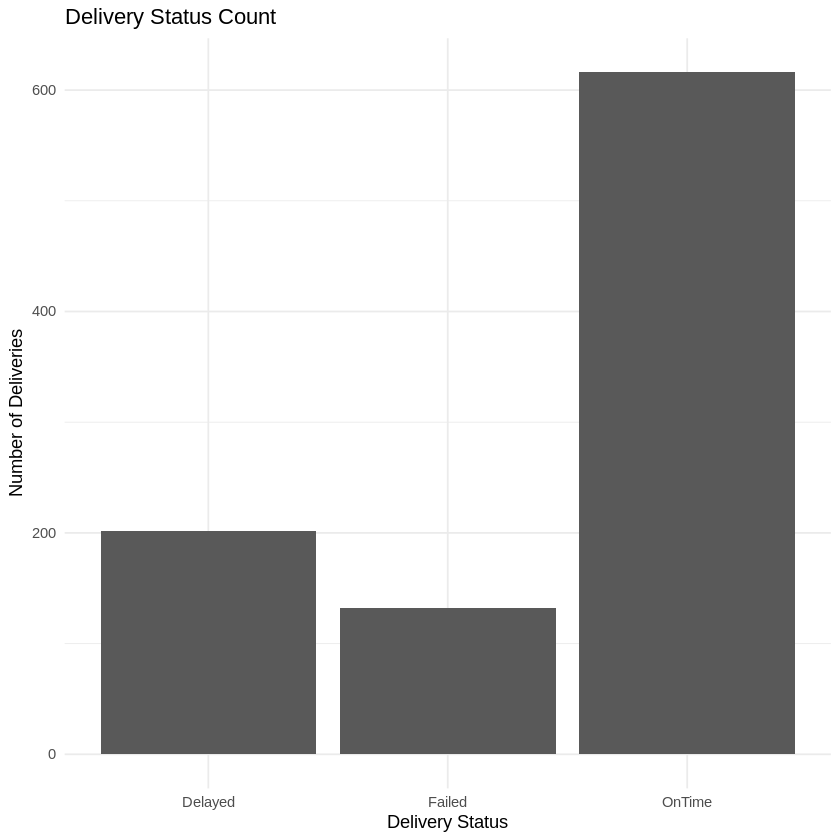

In [9]:
delivery_status_chart <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(count = n(), .groups = "drop")

delivery_status_chart

ggplot(delivery_status_chart, aes(x = delivery_status, y = count)) +
  geom_col() +
  labs(
    title = "Delivery Status Count",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal()

## 6. Failure rate by zone

dropoff_zone,total_deliveries,failed_deliveries,failure_rate_percent,average_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>
Central,98,18,18.37,3.78
North,145,25,17.24,3.83
Ctr,49,7,14.29,3.73
South,130,18,13.85,3.85
Riverside,141,19,13.48,3.96
East,118,14,11.86,3.86
West,146,17,11.64,3.92
Airport,123,14,11.38,3.87


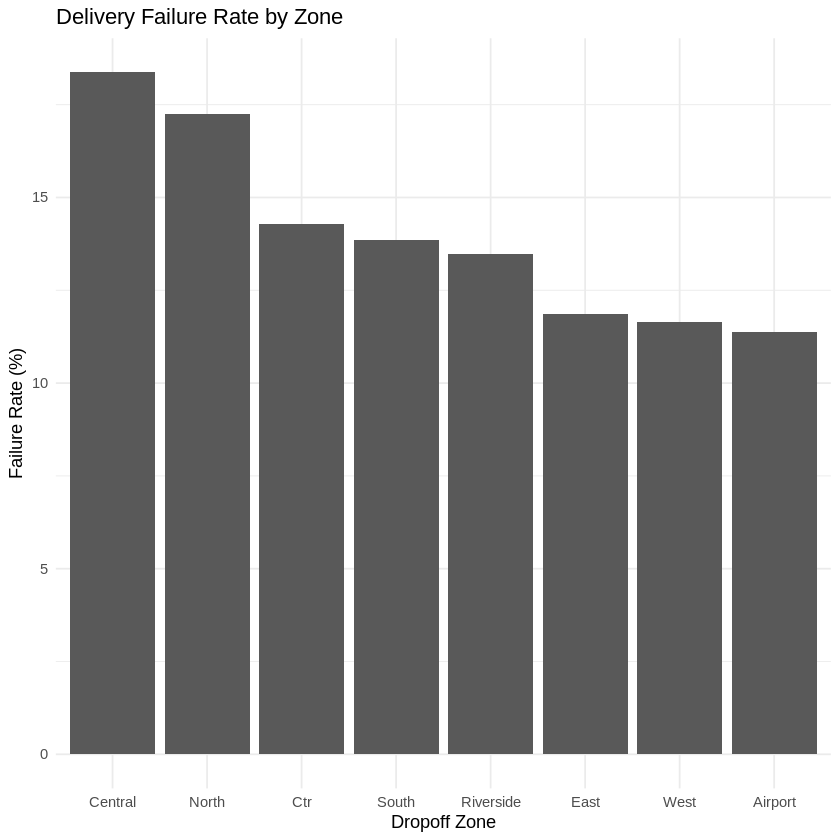

In [10]:
zone_chart <- ops %>%
  group_by(dropoff_zone) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(is_failed, na.rm = TRUE),
    failure_rate_percent = round(failed_deliveries / total_deliveries * 100, 2),
    average_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate_percent))

zone_chart

ggplot(zone_chart, aes(x = reorder(dropoff_zone, -failure_rate_percent), y = failure_rate_percent)) +
  geom_col() +
  labs(
    title = "Delivery Failure Rate by Zone",
    x = "Dropoff Zone",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

## 7. Complaints by type

complaint_type,count,average_compensation
<chr>,<int>,<dbl>
Delay,101,18.05149
MissedPickup,64,22.59365
AppIssue,53,19.61440
DriverBehaviour,51,21.15348
SupportExperience,20,17.12500
Billing,16,23.87125
Damage,15,23.98200


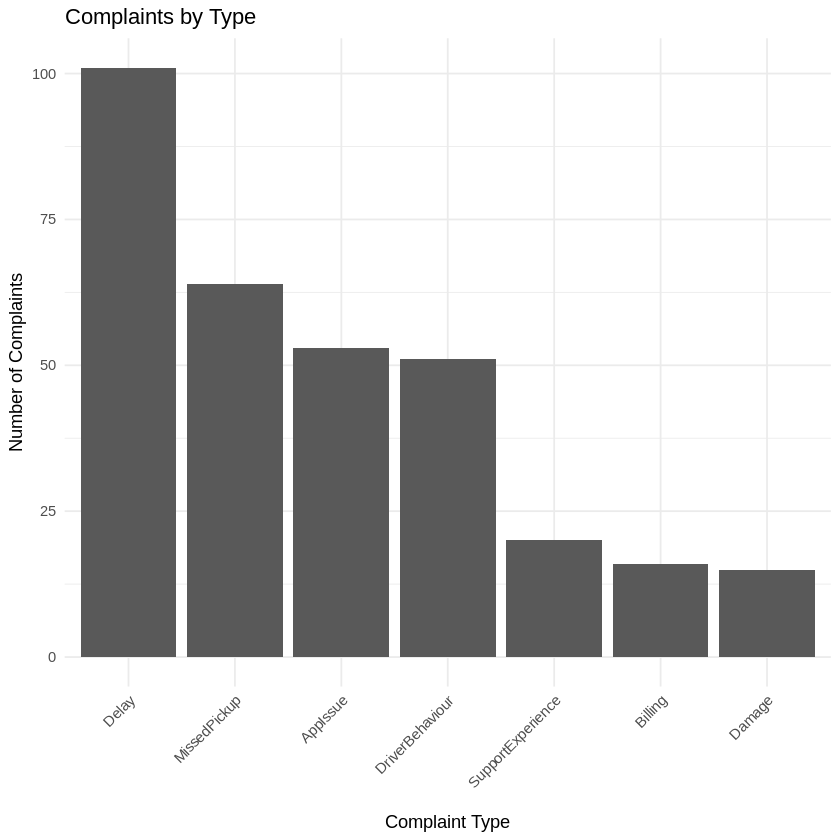

In [11]:
complaint_chart <- complaints %>%
  group_by(complaint_type) %>%
  summarise(count = n(), average_compensation = mean(compensation_amount, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(count))

complaint_chart

ggplot(complaint_chart, aes(x = reorder(complaint_type, -count), y = count)) +
  geom_col() +
  labs(
    title = "Complaints by Type",
    x = "Complaint Type",
    y = "Number of Complaints"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 8. Hub failure rate visualisation

hub_id,hub_name,total_deliveries,failed_deliveries,failure_rate_percent,average_rating
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
H08,Midtown Relay,128,26,20.31,3.88
H05,Central Core,115,23,20.00,3.67
H06,Airport Hub,104,15,14.42,3.88
H04,West Gate,127,16,12.60,3.92
H01,North Exchange,136,17,12.50,3.84
H07,Riverside Hub,115,14,12.17,3.88
H02,South Link,106,10,9.43,3.95
H03,East Dock,119,11,9.24,3.90


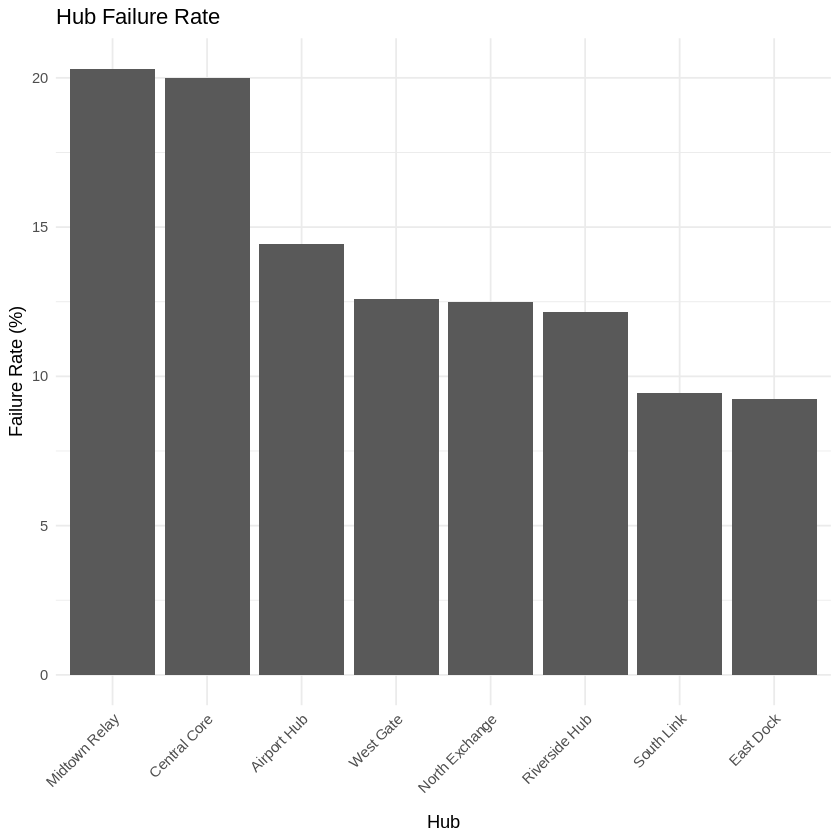

In [12]:
hub_chart <- ops %>%
  group_by(hub_id, hub_name) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(is_failed, na.rm = TRUE),
    failure_rate_percent = round(failed_deliveries / total_deliveries * 100, 2),
    average_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate_percent))

hub_chart

ggplot(hub_chart, aes(x = reorder(hub_name, -failure_rate_percent), y = failure_rate_percent)) +
  geom_col() +
  labs(
    title = "Hub Failure Rate",
    x = "Hub",
    y = "Failure Rate (%)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 9. Correlation analysis

In [13]:
cor_data <- deliveries %>%
  select(
    customer_rating_post_delivery,
    manual_route_override_count,
    fuel_or_charge_cost,
    delivery_duration_hours
  ) %>%
  na.omit()

correlation_matrix <- cor(cor_data)
correlation_matrix

,customer_rating_post_delivery,manual_route_override_count,fuel_or_charge_cost,delivery_duration_hours
customer_rating_post_delivery,1.00000000,-0.05792432,-0.06679436,-0.30479281
manual_route_override_count,-0.05792432,1.00000000,0.09507340,-0.01563630
fuel_or_charge_cost,-0.06679436,0.09507340,1.00000000,0.04414419
delivery_duration_hours,-0.30479281,-0.01563630,0.04414419,1.00000000


## 10. Route overrides vs customer rating

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


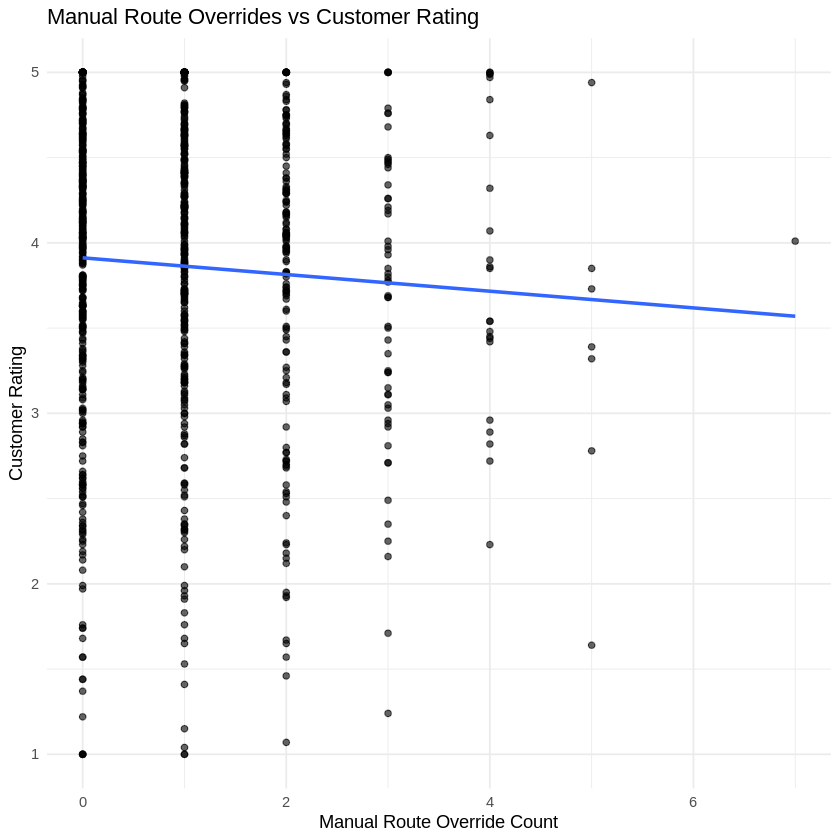

In [14]:
ggplot(deliveries, aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Manual Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  ) +
  theme_minimal()

## 11. App reliability analytics

event_type,event_count,average_api_latency_ms,success_rate_percent
<chr>,<int>,<dbl>,<dbl>
delivery_instruction_update,75,496.29,100.00
chat_opened,88,478.33,100.00
chat_escalated,38,478.13,50.00
payment_retry,69,472.68,72.46
track_order,138,460.71,100.00
search_route,99,456.51,100.00
eta_refresh,105,452.15,100.00
cancel_attempt,28,417.14,100.00


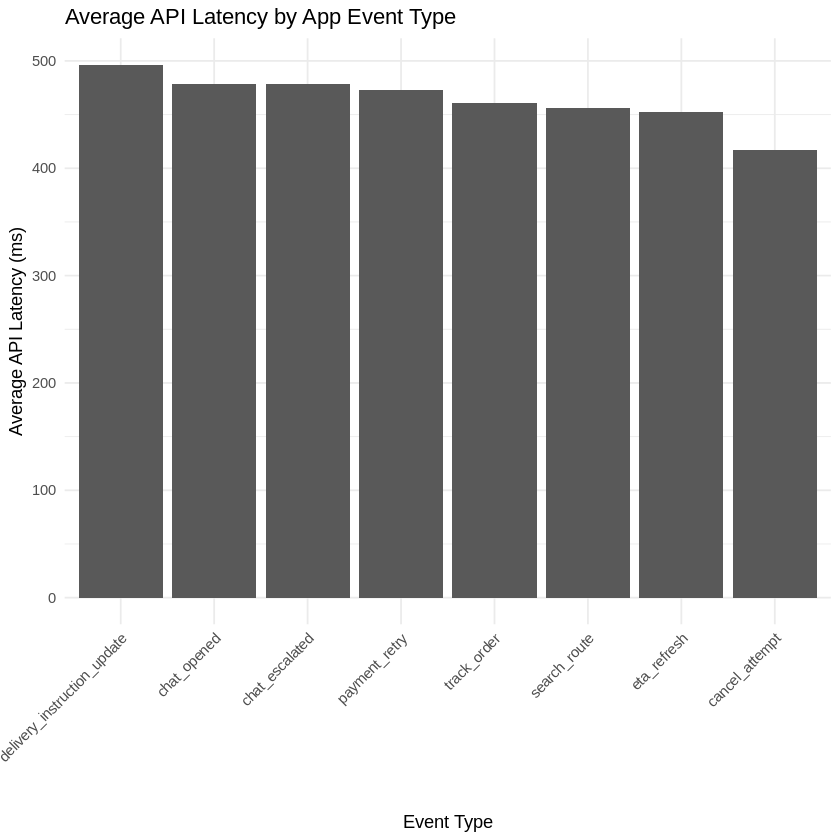

In [15]:
app_reliability <- app_events %>%
  group_by(event_type) %>%
  summarise(
    event_count = n(),
    average_api_latency_ms = round(mean(api_latency_ms, na.rm = TRUE), 2),
    success_rate_percent = round(mean(success_flag, na.rm = TRUE) * 100, 2),
    .groups = "drop"
  ) %>%
  arrange(desc(average_api_latency_ms))

app_reliability

ggplot(app_reliability, aes(x = reorder(event_type, -average_api_latency_ms), y = average_api_latency_ms)) +
  geom_col() +
  labs(
    title = "Average API Latency by App Event Type",
    x = "Event Type",
    y = "Average API Latency (ms)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 12. Incident analytics

incident_type,count,average_resolved_hours
<chr>,<int>,<dbl>
ProofMissing,46,10.767500
CustomerNoShow,44,13.888095
RouteDeviation,43,13.726829
VehicleFault,37,9.150000
BatteryAlert,36,11.708824
AppSyncError,31,12.657143
TemperatureIssue,29,12.917241
SafetyNearMiss,14,9.669231


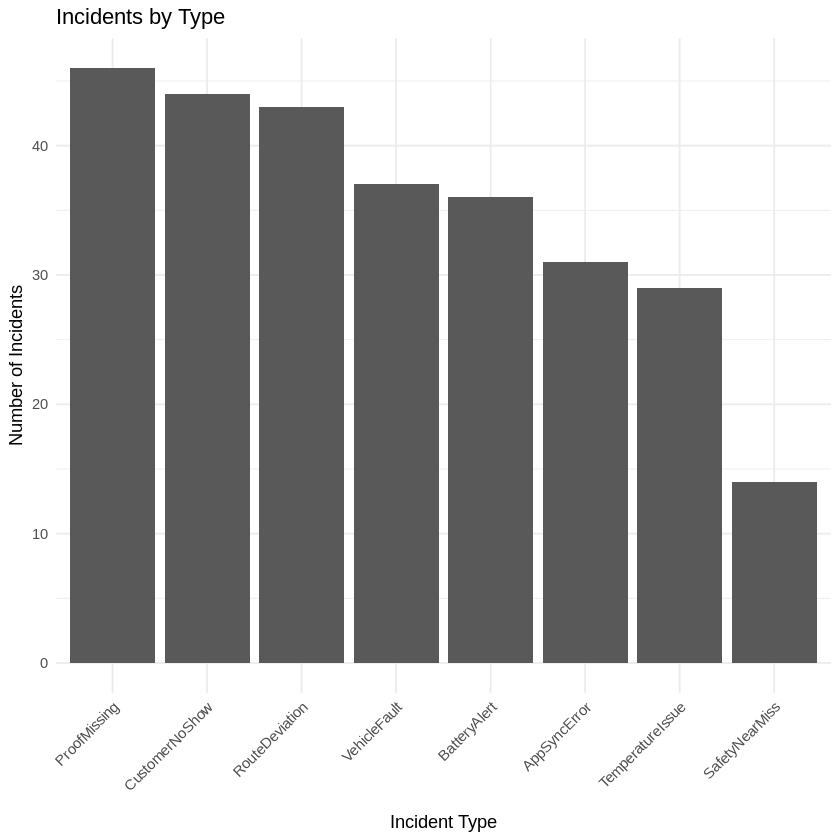

In [16]:
incident_chart <- incidents %>%
  group_by(incident_type) %>%
  summarise(count = n(), average_resolved_hours = mean(resolved_hours, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(count))

incident_chart

ggplot(incident_chart, aes(x = reorder(incident_type, -count), y = count)) +
  geom_col() +
  labs(
    title = "Incidents by Type",
    x = "Incident Type",
    y = "Number of Incidents"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 13. Export R analytics outputs

In [17]:
dir.create("r_analytics_outputs", showWarnings = FALSE)

write_csv(delivery_status_chart, "r_analytics_outputs/delivery_status_chart.csv")
write_csv(zone_chart, "r_analytics_outputs/zone_chart.csv")
write_csv(complaint_chart, "r_analytics_outputs/complaint_chart.csv")
write_csv(hub_chart, "r_analytics_outputs/hub_chart.csv")
write_csv(app_reliability, "r_analytics_outputs/app_reliability.csv")
write_csv(incident_chart, "r_analytics_outputs/incident_chart.csv")

print(list.files("r_analytics_outputs"))

[1] "app_reliability.csv"       "complaint_chart.csv"      
[3] "delivery_status_chart.csv" "hub_chart.csv"            
[5] "incident_chart.csv"        "zone_chart.csv"           
